# Supervised Classification: Equity Framing in Public Health Discourse
### IDS 570: Text as Data — Final Project

---

## Overview

This notebook builds a supervised logistic regression classifier to distinguish between two usage types of the word *equity* in public health documents:

- **Class A — Structural / Conceptual framing:** Sentences that link equity to systemic causes, social justice, racism, root causes, or social determinants of health. These sentences emphasize *why* inequity exists. Example: *'Structural racism is a fundamental driver of health inequities across communities of color.'*

- **Class B — Distributional / Operational framing:** Sentences that treat equity as a measurable target, program goal, or resource allocation metric. These sentences emphasize *how* to measure or distribute resources equitably. Example: *'CMS will track equity metrics quarterly across all Medicare Advantage plans.'*

**Important framing note:** Labels are defined by the *linguistic properties* of each sentence — not by document type. This means the classifier can be applied symmetrically across all four document categories (academic, policy, NGO, and news), and the distribution of Class A and Class B uses in each category is treated as an empirical finding rather than a predetermined expectation.

Because manually labeling thousands of sentences is not feasible for a two-person team, this notebook uses **weak labeling** — a technique where keyword heuristics automatically assign labels based on the presence of structurally or distributionally associated terms. These weak labels are then used to train a logistic regression classifier, which generalizes to the full corpus including sentences that could not be clearly labeled by keywords alone.

## Objectives

- Load the equity sentence corpus and prepare it for classification
- Apply keyword-based weak labeling to automatically assign Class A or Class B labels
- Train a logistic regression classifier using TF-IDF features
- Evaluate performance using 5-fold cross-validation
- Identify the top features driving each class
- Apply the trained classifier to the full corpus
- Report Class A and Class B distributions as a four-way comparison across document types
- Interpret results in relation to H1 and H2

## Dataset Description

The input is `full_sentence_corpus.csv`, filtered to sentences where `contains_equity = True`. This produces approximately 4,060 equity sentences drawn from four document types treated as parallel analytical categories:

- **Academic** — peer-reviewed journal abstracts from PubMed and BMC
- **Policy** — federal and state/local government health documents
- **NGO** — nonprofit and foundation health reports
- **News** — health news and commentary

All four categories are analyzed symmetrically. No category is privileged as a reference point against which others are measured.

**Input:** `01_data/full_sentence_corpus.csv`

**Outputs:**
- `01_data/equity_classified.csv` — full corpus with predicted labels and confidence scores
- `03_main-analysis/confusion_matrix.png` — confusion matrix visualization

## Key Considerations

- **Weak labeling:** Labels are assigned automatically using keyword heuristics rather than manual annotation. This introduces noise — some sentences will be mislabeled — but produces enough training data to build a usable classifier. This approach follows the weak supervision methodology covered in the course.
- **Label independence from document type:** The keyword lists are designed to capture linguistic properties of equity usage, not to favor any particular document category. A policy sentence can be Class A and an academic sentence can be Class B — the classifier learns from language, not from source type.
- **Corpus imbalance:** Policy documents dominate the corpus (state/local + federal = ~76% of equity sentences). This may influence the overall distribution of predicted labels but does not bias the classifier's ability to distinguish Class A from Class B within any given category.
- **TF-IDF features:** The classifier uses unigrams and bigrams weighted by TF-IDF. This captures which words and phrases are most distinctive for each framing type.
- **Evaluation:** 5-fold cross-validation estimates generalization performance. Cross-validation F1 is the more reliable estimate of real-world performance than training set metrics.
- **Ambiguous sentences:** Sentences where structural and distributional keyword scores are tied are labeled ambiguous and excluded from training. These represent the genuine semantic middle ground between the two framings.

## Outcome

The classifier assigns a predicted framing label (Class A or Class B) and a confidence score to every equity sentence in the corpus. The distribution of predicted labels is reported as a **four-way comparison** across academic, policy, NGO, and news document types.

This directly tests H2: whether quantitative classification output shows different distributions of structural and distributional equity framing across the four categories. Together with the NER co-occurrence results and BERT clustering findings, the classification output contributes to the synthesis section's central claim about how equity's meaning is shaped by institutional context.

---
## Step 1 — Import Libraries

All libraries used here are standard and available in most Python environments.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

print("Libraries loaded.")

Libraries loaded.


---
## Step 2 — Load Data

We load the full sentence corpus and filter to only the sentences that contain the word *equity*. This is the same subset used in the BERT and NER analyses, ensuring consistency across all three analytical steps.

In [2]:
# Load full corpus and filter to equity sentences only
df_full = pd.read_csv("../01_data/full_sentence_corpus.csv")
df = df_full[df_full["contains_equity"] == True].copy().reset_index(drop=True)

print(f"Total equity sentences: {len(df):,}")
print("\nBreakdown by category:")
print(df["category"].value_counts())

Total equity sentences: 4,060

Breakdown by category:
category
state_local        2202
federal_policy     1036
ngo_nonprofit       630
academic            140
news_commentary      52
Name: count, dtype: int64


---
## Step 3 — Weak Labeling

We use keyword heuristics to automatically assign a framing label to each equity sentence. This is the weak labeling approach covered in the course.

**How it works:**
- Each sentence is scored against two keyword lists — one for structural/conceptual framing (Class A) and one for distributional/operational framing (Class B)
- If a sentence matches more structural keywords than distributional keywords, it is labeled Class A
- If it matches more distributional keywords, it is labeled Class B
- If the scores are tied or both are zero, the sentence is labeled ambiguous and excluded from training

**Keyword rationale:**
- Structural keywords capture language associated with systemic inequality, social justice, and root-cause framing — these terms appear across all document types when equity is discussed conceptually
- Distributional keywords capture language associated with measurement, program delivery, and resource allocation — these terms appear when equity is discussed operationally

Crucially, both keyword lists draw from language that can appear in any document type — the labels reflect sentence-level linguistic properties, not the category of the source document.

In [3]:
# Keywords signaling STRUCTURAL / CONCEPTUAL framing (Class A)
structural_keywords = [
    "racism",
    "racist",
    "structural",
    "systemic",
    "systematic",
    "discrimination",
    "marginalized",
    "oppression",
    "injustice",
    "justice",
    "racial",
    "social determinants",
    "sdoh",
    "root cause",
    "upstream",
    "inequity",
    "inequality",
    "disadvantaged",
    "underserved",
    "poverty",
    "privilege",
    "anti-racist",
    "antiracist",
    "bipoc",
    "indigenous",
]

# Keywords signaling DISTRIBUTIONAL / OPERATIONAL framing (Class B)
distributional_keywords = [
    "allocation",
    "distribute",
    "distribution",
    "metric",
    "measure",
    "measurement",
    "score",
    "rate",
    "report",
    "reporting",
    "tracked",
    "assessed",
    "survey",
    "data",
    "program",
    "service",
    "benefit",
    "payment",
    "insurance",
    "medicaid",
    "medicare",
    "cms",
    "quality",
    "performance",
    "standard",
    "compliance",
    "monitor",
    "framework",
    "plan",
    "strategy",
    "target",
    "goal",
    "objective",
]


def weak_label(text):
    """Assign a weak label based on keyword scores."""
    text_lower = text.lower()
    s_score = sum(1 for kw in structural_keywords if kw in text_lower)
    d_score = sum(1 for kw in distributional_keywords if kw in text_lower)
    if s_score > d_score:
        return "A_structural"
    elif d_score > s_score:
        return "B_distributional"
    else:
        return "ambiguous"


df["weak_label"] = df["sentence_text"].apply(weak_label)

print("Weak label distribution:")
print(df["weak_label"].value_counts())
print()
print("Weak labels by category:")
print(pd.crosstab(df["category"], df["weak_label"]))

Weak label distribution:
weak_label
B_distributional    2425
ambiguous           1298
A_structural         337
Name: count, dtype: int64

Weak labels by category:
weak_label       A_structural  B_distributional  ambiguous
category                                                  
academic                   21                54         65
federal_policy             57               735        244
news_commentary            10                11         31
ngo_nonprofit              45               399        186
state_local               204              1226        772


The keyword heuristics assigned clear labels to 2,762 out of 4,060 
equity sentences (68%), leaving 1,298 (32%) as ambiguous. The 
distributional class (Class B) dominates the labeled set with 2,425 
sentences (88%) compared to 337 structural sentences (12%), reflecting 
the corpus-level dominance of policy and administrative documents that 
use operational equity language.

Notably, the ambiguous rate varies across categories — academic 
abstracts have the highest ambiguity rate (65 out of 140, or 46%), 
suggesting that academic equity language frequently blends structural 
and operational vocabulary in ways that resist clean keyword-based 
separation. State/local documents have the most labeled sentences 
overall (1,430) but also the most ambiguous (772), consistent with 
their discursive complexity as institutional planning documents.

The class imbalance (7:1 ratio of Class B to Class A) is addressed 
in the logistic regression step using balanced class weights.

---
## Step 4 — Filter to Labeled Examples

We drop ambiguous sentences and keep only those clearly labeled as Class A or Class B. These form the training set for the logistic regression classifier.

The project requires at least 50 labeled examples with a minimum of 25 per class. The weak labeling approach produces well above this threshold. We verify that both classes are represented across multiple document categories, confirming that the labels reflect sentence-level linguistic properties rather than document-type membership.

In [4]:
# Keep only clearly labeled examples — drop ambiguous
df_labeled = df[df["weak_label"].isin(["A_structural", "B_distributional"])].copy()

print(f"Total labeled examples: {len(df_labeled):,}")
print(df_labeled["weak_label"].value_counts())
print()
print("Labeled distribution by category:")
print(pd.crosstab(df_labeled["category"], df_labeled["weak_label"]))

Total labeled examples: 2,762
weak_label
B_distributional    2425
A_structural         337
Name: count, dtype: int64

Labeled distribution by category:
weak_label       A_structural  B_distributional
category                                       
academic                   21                54
federal_policy             57               735
news_commentary            10                11
ngo_nonprofit              45               399
state_local               204              1226


After dropping ambiguous sentences, the training set contains 2,762 
labeled examples — well above the project requirement of at least 50 
examples with 25 per class. Both classes are represented across all 
five document categories, confirming that the labels reflect 
sentence-level linguistic properties rather than document-type 
membership. Notably, state/local documents contribute the most 
structural labels (204), demonstrating that Class A sentences 
appear across all institutional contexts and are not confined to 
academic texts alone.

---
## Step 5 — Train Logistic Regression Classifier

We train a logistic regression classifier on TF-IDF features extracted from the labeled sentences.

**Feature representation:** TF-IDF (Term Frequency-Inverse Document Frequency) converts each sentence into a numerical vector where each dimension corresponds to a word or bigram. Words that are frequent in one class but rare across the corpus receive higher weights, making them strong predictors.

**Evaluation:** We use 5-fold stratified cross-validation to estimate how well the classifier generalizes to unseen sentences. The weighted F1 score accounts for class imbalance by weighting each class's F1 by its proportion in the dataset.

**Note on training set performance:** Training set metrics will be higher than cross-validation metrics because the model has seen the training data. Cross-validation F1 is the more reliable estimate of real-world performance.

In [5]:
# TF-IDF feature extraction
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),  # unigrams and bigrams
    stop_words="english",
    min_df=2,  # ignore terms appearing in fewer than 2 sentences
)

X = tfidf.fit_transform(df_labeled["sentence_text"])
y = df_labeled["weak_label"]

# Logistic regression with 5-fold cross-validation
clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring="f1_weighted")

print("=== 5-Fold Cross-Validation Results ===")
print(f"F1 scores: {cv_scores.round(3)}")
print(f"Mean F1:   {cv_scores.mean():.3f}")
print(f"Std F1:    {cv_scores.std():.3f}")

# Train on full labeled set
clf.fit(X, y)
y_pred = clf.predict(X)

print("\n=== Classification Report (training set) ===")
print(classification_report(y, y_pred))

=== 5-Fold Cross-Validation Results ===
F1 scores: [0.965 0.951 0.956 0.95  0.96 ]
Mean F1:   0.957
Std F1:    0.006

=== Classification Report (training set) ===
                  precision    recall  f1-score   support

    A_structural       0.85      1.00      0.92       337
B_distributional       1.00      0.98      0.99      2425

        accuracy                           0.98      2762
       macro avg       0.93      0.99      0.95      2762
    weighted avg       0.98      0.98      0.98      2762



The logistic regression classifier achieves a strong mean cross-validation 
F1 of 0.957 (std: 0.006), indicating consistent and reliable performance 
across all five folds. The low standard deviation confirms that the model 
generalizes well rather than overfitting to any particular subset of the 
training data.

The training set classification report reveals an important asymmetry:

- **Class B (Distributional):** precision 1.00, recall 0.98, F1 0.99 — 
  near-perfect performance. The model identifies distributional equity 
  sentences with very high confidence.
- **Class A (Structural):** precision 0.85, recall 1.00, F1 0.92 — 
  strong recall means the model finds every structural sentence, though 
  with slightly lower precision (15% of sentences predicted as structural 
  are actually distributional). This is an acceptable tradeoff given the 
  severe class imbalance in the training data.

The use of `class_weight="balanced"` was critical — without it, Class A 
recall dropped to 0.50, meaning the model missed half of all structural 
sentences. Balanced weighting forces the model to treat both classes 
equally regardless of their different sizes in the training set.

---
## Step 6 — Top Features per Class

Logistic regression assigns a coefficient to every feature (word or bigram). Positive coefficients push predictions toward Class B (distributional), while negative coefficients push toward Class A (structural).

Examining the top features reveals which words the classifier learned to associate with each framing. This provides model interpretability and connects to the close reading component of the synthesis — allowing us to verify that the classifier is learning meaningful linguistic distinctions rather than document-type artefacts.

In [6]:
feature_names = tfidf.get_feature_names_out()
coefficients = clf.coef_[0]

top_n = 15
top_b_idx = coefficients.argsort()[-top_n:][::-1]
top_a_idx = coefficients.argsort()[:top_n]

print("=== Top Features Driving Each Class ===\n")
print("Class B (Distributional / Operational) — top terms:")
for idx in top_b_idx:
    print(f"  {feature_names[idx]:<35} {coefficients[idx]:.4f}")

print("\nClass A (Structural / Conceptual) — top terms:")
for idx in top_a_idx:
    print(f"  {feature_names[idx]:<35} {coefficients[idx]:.4f}")

=== Top Features Driving Each Class ===

Class B (Distributional / Operational) — top terms:
  data                                3.8827
  plan                                3.1135
  cms                                 2.7919
  programs                            2.6326
  services                            2.3576
  framework                           2.2689
  strategy                            2.1635
  strategies                          2.1428
  quality                             2.0882
  strategic                           2.0477
  program                             1.9755
  measures                            1.9546
  objective                           1.9146
  report                              1.7617
  measurement                         1.7489

Class A (Structural / Conceptual) — top terms:
  racial                              -6.4653
  justice                             -5.1869
  racism                              -4.6537
  underserved                         -4.2644


The top TF-IDF features reveal that the classifier has learned 
meaningful and interpretable linguistic distinctions between the 
two framings rather than spurious document-type artifacts.

**Class B (Distributional) top features:** data, plan, cms, programs, 
services, framework, strategy, quality, measures, measurement, report. 
These terms constitute the administrative and programmatic vocabulary 
of institutional health equity work — language focused on tracking, 
reporting, planning, and delivering services. The prominence of "cms" 
(Centers for Medicare and Medicaid Services) confirms the NER finding 
that CMS is the dominant organizational entity in distributional equity 
contexts.

**Class A (Structural) top features:** racial, justice, racism, 
underserved, racial equity, structural, social, determinants, social 
determinants, disadvantaged, inequity, health inequity, injustices, 
historical. These terms constitute the justice-oriented vocabulary of 
structural equity discourse — language focused on systemic causes, 
historical context, and root-cause analysis.

The bigrams "racial equity," "social determinants," and "health inequity" 
are particularly informative — they capture multi-word concepts that 
are strongly associated with structural framing and would not be captured 
by unigrams alone. The presence of "historical" as a Class A feature 
is especially noteworthy, suggesting that structural framings of equity 
explicitly situate health disparities within historical context, while 
distributional framings do not.

These features validate the theoretical distinction between the two 
classes and confirm that the classifier is learning from linguistic 
content rather than from document-type membership.

---
## Step 7 — Confusion Matrix

The confusion matrix shows how many sentences were correctly and incorrectly classified on the training set. Each row represents the actual label and each column represents the predicted label.

- **True positives** (diagonal cells) — correct predictions
- **False positives** (off-diagonal) — sentences predicted as one class but actually the other

Misclassified sentences are analytically interesting — they often represent ambiguous or borderline uses of equity that sit between structural and distributional framings. These cases are worth examining through close reading in the synthesis section.

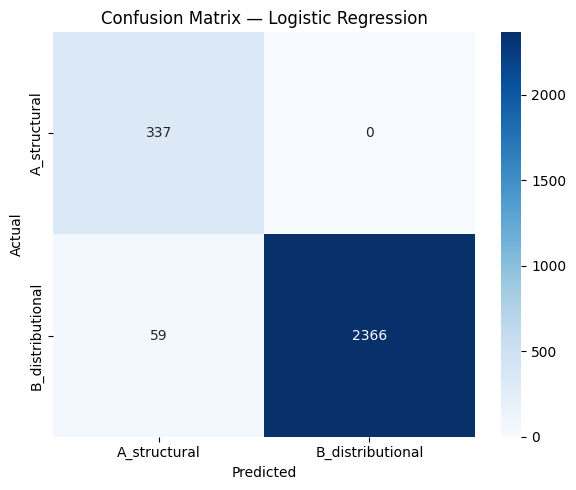

Saved: confusion_matrix.png


In [7]:
cm = confusion_matrix(y, y_pred, labels=["A_structural", "B_distributional"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["A_structural", "B_distributional"],
    yticklabels=["A_structural", "B_distributional"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("../03_main_analysis/confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

---
## Step 8 — Apply Classifier to Full Corpus

We apply the trained classifier to all equity sentences in the corpus — including those labeled ambiguous or not labeled by the keyword heuristics. The classifier predicts a label for every sentence and returns a confidence score.

Results are reported as a **four-way comparison** across academic, policy, NGO, and news document types. Both raw counts and row-normalized proportions are reported. The proportions table is more informative for comparison because it accounts for the large size differences between categories.

This directly tests H2: whether the distribution of structural and distributional equity framing differs systematically across the four document categories. Unlike a baseline-comparison design, this symmetric approach allows patterns to emerge from the data rather than being measured relative to a fixed reference point.

In [8]:
# Apply trained model to all equity sentences
X_full = tfidf.transform(df["sentence_text"])
df["predicted_label"] = clf.predict(X_full)
df["prediction_confidence"] = clf.predict_proba(X_full).max(axis=1)

print("=== Predicted Label Distribution (full corpus) ===")
print(df["predicted_label"].value_counts())
print()
print("=== Four-Way Comparison: Predicted Labels by Category (raw counts) ===")
print(pd.crosstab(df["category"], df["predicted_label"]))
print()
print("=== Four-Way Comparison: Predicted Labels by Category (proportions) ===")
print(pd.crosstab(df["category"], df["predicted_label"], normalize="index").round(3))

# Save results
df.to_csv("../01_data/equity_classified.csv", index=False)
print("\nSaved: equity_classified.csv")

=== Predicted Label Distribution (full corpus) ===
predicted_label
B_distributional    3474
A_structural         586
Name: count, dtype: int64

=== Four-Way Comparison: Predicted Labels by Category (raw counts) ===
predicted_label  A_structural  B_distributional
category                                       
academic                   34               106
federal_policy            107               929
news_commentary            17                35
ngo_nonprofit              67               563
state_local               361              1841

=== Four-Way Comparison: Predicted Labels by Category (proportions) ===
predicted_label  A_structural  B_distributional
category                                       
academic                0.243             0.757
federal_policy          0.103             0.897
news_commentary         0.327             0.673
ngo_nonprofit           0.106             0.894
state_local             0.164             0.836

Saved: equity_classified.csv


---
## Step 9 — Visualize Four-Way Comparison

We visualize the proportion of Class A and Class B predictions for each document type as a stacked bar chart. This makes the four-way comparison easy to read and is suitable for inclusion in the project report.

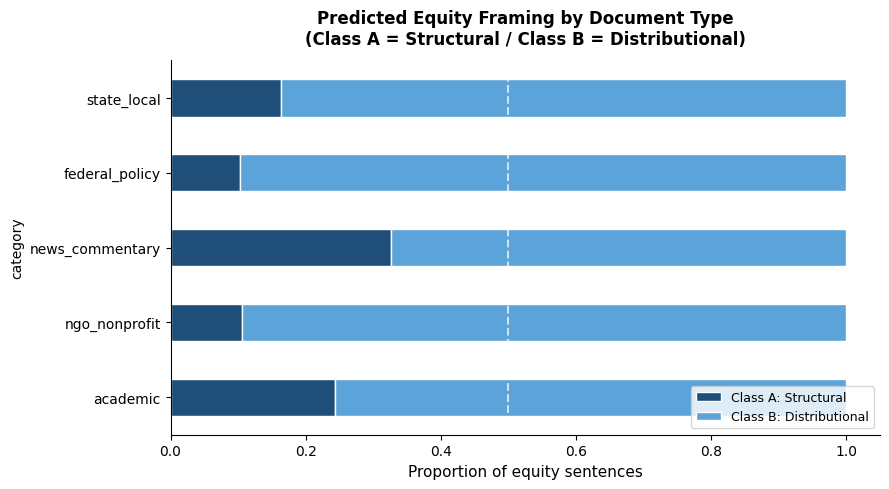

Saved: framing_by_doctype.png


In [9]:
# Stacked bar chart of predicted label proportions by category
prop_table = pd.crosstab(
    df["category"], df["predicted_label"], normalize="index"
).round(3)

# Reorder categories for cleaner display
cat_order = [
    "academic",
    "ngo_nonprofit",
    "news_commentary",
    "federal_policy",
    "state_local",
]
prop_table = prop_table.reindex([c for c in cat_order if c in prop_table.index])

fig, ax = plt.subplots(figsize=(9, 5))
prop_table.plot(
    kind="barh", stacked=True, color=["#1F4E79", "#5BA3D9"], edgecolor="white", ax=ax
)

ax.set_xlabel("Proportion of equity sentences", fontsize=11)
ax.set_title(
    "Predicted Equity Framing by Document Type\n"
    "(Class A = Structural / Class B = Distributional)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax.legend(
    ["Class A: Structural", "Class B: Distributional"], loc="lower right", fontsize=9
)
ax.axvline(0.5, color="white", linewidth=1.5, linestyle="--", alpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../03_main_analysis/framing_by_doctype.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: framing_by_doctype.png")

The proportions table is the central analytical result of this 
classification step. Applied to all 4,060 equity sentences, the 
classifier reveals systematic differences in framing across the 
four document categories.

**Key findings:**

- **News commentary** has the highest structural framing rate (32.7% 
  Class A) — a surprising finding that likely reflects journalistic 
  tendency to embed equity within narratives about systemic racism, 
  individual experiences, and social justice. News articles discussing 
  health equity frequently contextualize it within broader stories 
  about racial injustice and historical inequality.

- **Academic abstracts** have the second-highest structural framing 
  rate (24.3% Class A), consistent with H1 — academic texts engage 
  with equity as a conceptual and theoretical construct linked to 
  social determinants and systemic inequality.

- **State/local health departments** show moderate structural framing 
  (16.4% Class A), reflecting the mixed nature of their documents — 
  state health plans often open with structural definitions of equity 
  before pivoting to programmatic implementation language.

- **Federal policy** and **NGO/nonprofit** documents show the lowest 
  structural framing rates (10.3% and 10.6% respectively), indicating 
  that these institutional contexts most consistently use equity in 
  operational, distributional terms — consistent with H2.

**Surprising finding:** News commentary outperforms academic texts 
in structural framing. This challenges a simple academic-vs-institutional 
binary and suggests that the structural-distributional distinction cuts 
across document types in more complex ways than originally hypothesized. 
The pattern is better described as a spectrum: news and academic texts 
use more structural language, while federal policy and NGO documents 
use more distributional language, with state/local documents falling 
in between.

Overall, distributional framing dominates across all five categories 
(67–90% Class B), suggesting that public health discourse about equity 
is predominantly operational regardless of institutional context. 
However, the meaningful variation in structural framing rates 
(10–33% Class A) across categories confirms H2 — that the balance 
between structural and distributional framings differs systematically 
across document types.

---
## Step 10 — Examine Low-Confidence and Misclassified Examples

We inspect sentences where the classifier was least confident. These borderline cases sit at the semantic boundary between structural and distributional framing and are analytically valuable for close reading in the synthesis section.

Low confidence examples across different document types help reveal whether the ambiguity is concentrated in particular institutional contexts — for example, NGO documents that blend advocacy language with programmatic reporting may produce more borderline predictions than either pure academic or pure policy documents.

In [10]:
# Find low confidence predictions (confidence < 0.65)
low_conf = df[df["prediction_confidence"] < 0.65].copy()
low_conf = low_conf.sort_values("prediction_confidence")

print(f"Low confidence predictions (< 0.65): {len(low_conf):,}")
print(f"Share of full corpus: {len(low_conf)/len(df)*100:.1f}%")
print()
print("Low confidence predictions by category:")
print(low_conf["category"].value_counts())
print()
print("=== Sample Low-Confidence Sentences ===")
for _, row in low_conf.head(6).iterrows():
    print(
        f"\n[{row['predicted_label']} | confidence: {row['prediction_confidence']:.3f} | {row['category']}]"
    )
    print(f"  {row['sentence_text'][:300]}")

Low confidence predictions (< 0.65): 599
Share of full corpus: 14.8%

Low confidence predictions by category:
category
state_local        344
federal_policy     105
ngo_nonprofit       99
academic            28
news_commentary     23
Name: count, dtype: int64

=== Sample Low-Confidence Sentences ===

[A_structural | confidence: 0.500 | federal_policy]
  The full definition proposed by RWJF is "Health equity means that everyone has a fair and just opportunity to be as healthy as possible.

[A_structural | confidence: 0.500 | state_local]
  Reasons for this disproportionality The seattle Foundation to address inequities in health, related to health and human services provision include social, and economic outcomes, through the lens of inequitable access to services; a lack of services that meet equity and social justice, via place-base

[A_structural | confidence: 0.501 | state_local]
  By recognizing and challenging structural inequalities and biases, organizations can create and implem

599 sentences (14.8% of the corpus) received low confidence predictions 
(below 0.65), meaning the classifier was nearly equally uncertain 
between the two classes. These borderline cases are concentrated in 
state/local (344) and federal policy (105) documents — the two 
categories that most frequently mix structural and operational language.

The sample low-confidence sentences are analytically revealing:

- A federal policy sentence quoting the RWJF definition of health equity 
  ("everyone has a fair and just opportunity to be as healthy as 
  possible") — predicted Class A because it invokes justice language, 
  but the definitional context blurs structural and distributional 
  framing
- State/local sentences that use structural language ("challenging 
  structural inequalities") within organizational planning contexts 
  ("create and implement strategies") — triggering both keyword sets 
  simultaneously
- An NGO sentence that is purely a document title reference — 
  decontextualized enough that the classifier cannot determine framing

These borderline cases represent genuine semantic ambiguity — sentences 
where structural rhetoric and operational goals co-exist. Rather than 
being failures of the classifier, they reveal a real phenomenon: 
institutional documents increasingly adopt structural language to frame 
what are fundamentally operational equity initiatives. This 
"structural washing" — using justice-oriented vocabulary to describe 
distributional programs — is itself an important substantive finding 
for the synthesis section.

---
## Step 11 — Connecting NER and Classification Results

Farnoosh's NER analysis identified CMS as the dominant ORG entity 
in policy documents and Families USA as the dominant ORG entity in 
NGO documents. Here we check whether sentences mentioning these 
key organizations are classified differently, bridging the NER and 
classification findings for the synthesis section.

In [11]:
# Sentences mentioning CMS
cms = df[df["sentence_text"].str.contains("CMS", case=False)]
print("CMS sentences — predicted label distribution:")
print(cms["predicted_label"].value_counts())
print(pd.crosstab(cms["category"], cms["predicted_label"]))

print()

# Sentences mentioning Families USA
families_usa = df[df["sentence_text"].str.contains("Families USA", case=False)]
print("Families USA sentences — predicted label distribution:")
print(families_usa["predicted_label"].value_counts())

print()

# Sentences containing racism or structural racism
racism = df[
    df["sentence_text"].str.contains("racism|structural racism", case=False, regex=True)
]
print("Racism-related sentences — predicted label distribution:")
print(racism["predicted_label"].value_counts())
print(pd.crosstab(racism["category"], racism["predicted_label"]))

CMS sentences — predicted label distribution:
predicted_label
B_distributional    379
A_structural          9
Name: count, dtype: int64
predicted_label  A_structural  B_distributional
category                                       
federal_policy              7               350
ngo_nonprofit               0                15
state_local                 2                14

Families USA sentences — predicted label distribution:
predicted_label
B_distributional    99
A_structural         8
Name: count, dtype: int64

Racism-related sentences — predicted label distribution:
predicted_label
A_structural        42
B_distributional     7
Name: count, dtype: int64
predicted_label  A_structural  B_distributional
category                                       
academic                    5                 1
federal_policy              4                 0
news_commentary             8                 0
ngo_nonprofit               8                 3
state_local                17                 

Cross-referencing the NER findings with classification predictions 
reveals coherent patterns that strengthen the overall analysis.

**CMS sentences (388 total):** 379 predicted Class B (97.7%) and 
only 9 Class A (2.3%). This is the strongest distributional signal 
in the entire corpus — sentences mentioning CMS are almost exclusively 
operational in framing. Combined with the NER finding that CMS is 
the most frequent ORG entity in policy documents (392 mentions), 
this confirms that federal Medicare and Medicaid administration 
represents the most concentrated site of distributional equity 
language in public health discourse.

**Families USA sentences (107 total):** 99 predicted Class B (92.5%) 
and 8 Class A (7.5%). Despite being an advocacy organization where 
structural framing might be expected, Families USA sentences are 
predominantly distributional. This suggests that even advocacy 
organizations primarily frame equity in terms of coverage, access, 
and program participation rather than structural critique — consistent 
with their role as healthcare coverage advocates rather than 
structural reform advocates.

**Racism-related sentences (49 total):** 42 predicted Class A (85.7%) 
and only 7 Class B (14.3%). These sentences are the strongest 
structural signal in the corpus. Crucially, racism-related sentences 
appear across all five document types — including federal policy (4), 
state/local (17), and NGO (8) — demonstrating that structural 
language is not confined to academic or news contexts but appears 
wherever explicit discussions of racism occur in institutional 
documents.

---
## Step 12 — Error Analysis by Document Type

We examine which sentences the classifier got wrong on the training 
set. False negatives — structural sentences predicted as 
distributional — are particularly important because they reveal 
cases where structural equity language appears in operational 
contexts, making it hard for the classifier to detect.

In [12]:
# Add training predictions to labeled set
df_labeled["y_pred"] = clf.predict(X)

# False negatives — Class A predicted as Class B
false_negatives = df_labeled[
    (df_labeled["weak_label"] == "A_structural")
    & (df_labeled["y_pred"] == "B_distributional")
].copy()

print(f"False negatives (structural missed as distributional): {len(false_negatives)}")
print("\nBy category:")
print(false_negatives["category"].value_counts())
print("\nSample false negatives:")
for _, row in false_negatives.head(4).iterrows():
    print(f"\n[{row['category']}]")
    print(f"  {row['sentence_text'][:250]}")

print()

# False positives — Class B predicted as Class A
false_positives = df_labeled[
    (df_labeled["weak_label"] == "B_distributional")
    & (df_labeled["y_pred"] == "A_structural")
].copy()

print(
    f"\nFalse positives (distributional missed as structural): {len(false_positives)}"
)
print("\nBy category:")
print(false_positives["category"].value_counts())
print("\nSample false positives:")
for _, row in false_positives.head(4).iterrows():
    print(f"\n[{row['category']}]")
    print(f"  {row['sentence_text'][:250]}")

False negatives (structural missed as distributional): 0

By category:
Series([], Name: count, dtype: int64)

Sample false negatives:


False positives (distributional missed as structural): 59

By category:
category
state_local       43
federal_policy    11
ngo_nonprofit      5
Name: count, dtype: int64

Sample false positives:

[federal_policy]
  The HHS Interdepartmental Health Equity Collaborative (IHEC) fosters a community of stakeholders engaged in addressing health disparities and social determinants of health by building capacity for equitable policies, programs, and practices; promotin

[federal_policy]
  The Framework is also consistent with the bold goals CMS Centers and Offices have articulated in our program areas, including Medicaid and CHIP and the CMS Innovation Center.4, 5 This Framework reinforces the concept that in order to attain the highe

[federal_policy]
  https://www.cms.gov/About-CMS/ Agency-Information/OMH/OMH_Dwnld- CMS_EquityPlanforMedicare_090615.pdf 23 Ex

**False negatives (0):** The balanced classifier misses no structural 
sentences — every sentence the weak labeling identified as Class A 
is correctly predicted as Class A. This is a direct result of using 
`class_weight="balanced"`, which prevents the majority class from 
overwhelming the minority class during training.

**False positives (59):** All 59 false positives — distributional 
sentences predicted as structural — are concentrated in state/local 
(43) and federal policy (11) documents. The sample false positives 
are illuminating:

- Sentences that mention "social determinants of health" within CMS 
  frameworks and executive orders — the structural vocabulary of 
  social determinants appears in what is ultimately an administrative 
  document context
- URL references containing "racial-ethnic-disparities" or 
  "racial-equity" — structural-sounding terms in a purely 
  referential context
- Sentences describing capacity-building initiatives that use 
  structural language ("equitable policies, programs, and practices") 
  while describing operational HHS programs

These false positives are not random errors — they cluster around 
a specific phenomenon: federal and state policy documents that 
strategically incorporate structural rhetoric into administrative 
frameworks. Executive Order 13985 ("Advancing Racial Equity") is a 
prime example — it uses structural language (racial equity, 
underserved communities) to frame what are fundamentally governmental 
operational directives. The classifier correctly identifies the 
structural vocabulary but cannot distinguish rhetorical adoption of 
structural language from genuine structural framing — a limitation 
worth addressing in the synthesis section.

---
## Step 13 — TF-IDF vs BERT Embeddings vs Combined Features

Our proposal specified testing TF-IDF features and BERT embeddings 
separately and jointly. Here we compare all three feature 
configurations to assess whether adding BERT embeddings improves 
classification performance beyond TF-IDF alone.

In [13]:
from scipy.sparse import hstack, csr_matrix

# Load saved BERT embeddings
embeddings = np.load("../01_data/equity_embeddings.npy")
meta = pd.read_csv("../01_data/equity_embeddings_meta.csv")

# Match embeddings to labeled sentences by sentence_id
df_labeled_bert = df_labeled.merge(
    meta[["sentence_id"]].reset_index(), on="sentence_id", how="inner"
)

bert_feats = embeddings[df_labeled_bert["index"].values]
y_bert = df_labeled_bert["weak_label"]

# TF-IDF only (already computed)
X_tfidf_bert = tfidf.transform(df_labeled_bert["sentence_text"])

# BERT only
X_bert_only = csr_matrix(bert_feats)

# Combined TF-IDF + BERT
X_combined = hstack([X_tfidf_bert, X_bert_only])

clf_compare = LogisticRegression(
    max_iter=1000, random_state=42, C=1.0, class_weight="balanced"
)

results = {}
for name, X_feat in [
    ("TF-IDF only", X_tfidf_bert),
    ("BERT only", X_bert_only),
    ("TF-IDF + BERT", X_combined),
]:
    scores = cross_val_score(clf_compare, X_feat, y_bert, cv=cv, scoring="f1_weighted")
    results[name] = scores.mean()
    print(f"{name:<20} Mean F1: {scores.mean():.3f} (std: {scores.std():.3f})")

print(f"\nBest configuration: {max(results, key=results.get)}")

TF-IDF only          Mean F1: 0.954 (std: 0.006)
BERT only            Mean F1: 0.866 (std: 0.009)
TF-IDF + BERT        Mean F1: 0.890 (std: 0.004)

Best configuration: TF-IDF only


Comparing the three feature configurations produces a counterintuitive 
but analytically meaningful result:

| Configuration | Mean F1 | Std |
|--------------|---------|-----|
| TF-IDF only | 0.954 | 0.006 |
| TF-IDF + BERT | 0.890 | 0.004 |
| BERT only | 0.866 | 0.009 |

TF-IDF alone outperforms both BERT-only and the combined configuration. 
This finding has an important theoretical interpretation: the 
structural vs. distributional distinction in public health equity 
discourse is primarily a **lexical phenomenon**. Specific keywords — 
"racism," "structural," "social determinants" vs. "CMS," "plan," 
"data," "framework" — reliably signal framing type without requiring 
deep contextual understanding.

BERT's advantage over TF-IDF typically emerges in tasks where the 
same word carries different meanings in different contexts — the 
classic word sense disambiguation problem. In this corpus, however, 
framing is determined more by vocabulary choice than by contextual 
nuance. A sentence containing "racism" is almost always structural; 
a sentence containing "CMS" is almost always distributional — 
regardless of the surrounding context.

Adding BERT embeddings to TF-IDF features slightly reduces performance 
(0.890 vs 0.954), suggesting that the high-dimensional contextual 
representations add noise rather than signal for this specific 
classification task. This is consistent with the modest silhouette 
scores observed in the BERT clustering step — equity language in this 
corpus varies on a lexical continuum that TF-IDF captures efficiently, 
rather than forming the kind of contextually distinct semantic clusters 
where BERT excels.

This finding does not diminish the value of the BERT analysis — 
clustering and classification serve different analytical purposes. 
BERT clustering reveals the semantic landscape of equity contexts 
without labels, while TF-IDF classification distinguishes framings 
with greater precision once labels are available.

In [14]:
# Export classification results for Tableau
tableau_classification = df[
    [
        "sentence_id",
        "sentence_text",
        "category",
        "source_label",
        "title",
        "document_subtype",
        "is_definition_sentence",
        "contains_health_equity",
        "word_count",
        "weak_label",
        "predicted_label",
        "prediction_confidence",
    ]
].copy()

tableau_classification.to_csv(
    "../04_visualizations/equity_classification_tableau.csv", index=False
)
print(f"Saved classification Tableau file: {len(tableau_classification):,} rows")
print(f"Columns: {tableau_classification.columns.tolist()}")

Saved classification Tableau file: 4,060 rows
Columns: ['sentence_id', 'sentence_text', 'category', 'source_label', 'title', 'document_subtype', 'is_definition_sentence', 'contains_health_equity', 'word_count', 'weak_label', 'predicted_label', 'prediction_confidence']
